In [9]:
import jax
import jax.numpy as jnp
from jax import lax
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

In [3]:
from simulate import simulate_projectile, analytic_projectile

In [4]:
# Simulation parameters
v0 = 10 # initial speed m/s
theta = 20 # launch angle in deg
x0, y0 = 0, 0 # initial pos in meter
dt_values = jnp.array([0.01, 0.02, 0.04, 0.08, 0.16]) # second
end_time = 10 # second
n_steps = jnp.floor(end_time/dt_values) # number of steps

In [7]:
abs_err = []

for i in range(len(dt_values)):
    final_state, trajectory = simulate_projectile(
        x0=x0,
        y0=y0,
        v0=v0,
        theta=theta,
        dt=dt_values[i],
        n_steps=n_steps[i],
    )

    x_jax, y_jax = final_state[0], final_state[1]

    x_analytic, y_analytic = analytic_projectile(
        x0=x0,
        y0=y0,
        v0=v0,
        theta=theta,
        dt=dt_values[i],
        n_steps=n_steps[i],
    )

    y_exact = y_analytic[-1]

    error = jnp.abs(y_jax - y_exact)
    abs_err.append(error)

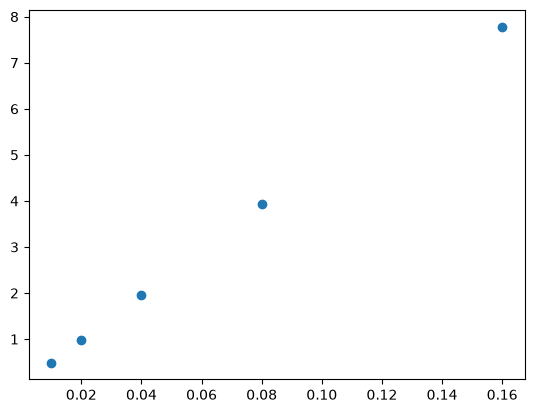

In [11]:
plt.scatter(dt_values, abs_err)